<a href="https://colab.research.google.com/github/bpizarrogalleguillos/IAmetodologia2025/blob/main/Met_No_Supervisados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Métodos no supervisados

En este cuaderno probaremos diferentes métodos de aprendizaje de máquinas no supervisados basados en un dataset clínico real de pacientes con distrofias musculares.


In [1]:
import pandas as pd


In [6]:
db = pd.read_csv("dryad_external_merge.csv")
db

,Code,patient__sex,patient__genetic_diagnosis,PsoasL,PsoasR,IliacusL,IliacusR,Glutei MaximumL,Glutei MaximumR,Glutei MediusL,...,Gastrocnemius laterallisL,Gastrocnemius lateralisR,SoleusL,SoleusR,FHL L,FHL R,Flexor digitorumL,Flexor digitorumR,Peroneus brevisL,Peroneus brevisR
0,1608,F,Dysf,3.0,3.0,3.0,3.0,3.0,3.0,2.0,...,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0
1,1609,M,Dysf,1.0,1.0,1.0,1.0,2.0,2.0,1.0,...,3.0,3.0,4.0,4.0,1.0,1.0,3.0,3.0,2.0,1.0
2,1610,M,Dysf,2.0,2.0,2.0,2.0,4.0,4.0,2.0,...,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0
3,1611,F,Dysf,1.0,1.0,1.0,1.0,2.0,2.0,1.0,...,1.0,3.0,2.0,2.0,1.0,1.0,1.0,1.0,3.0,2.0
4,1612,F,Dysf,NaN,NaN,NaN,NaN,3.0,3.0,3.0,...,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1026,Ano24,NaN,Ano,NaN,NaN,NaN,NaN,4,4,3,...,4,4,4,4,NaN,NaN,NaN,NaN,NaN,NaN
1027,Ano25,NaN,Ano,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4,4,4,2,NaN,NaN,NaN,NaN,NaN,NaN
1028,Ano26,NaN,Ano,NaN,NaN,NaN,NaN,1,1,1,...,4,4,4,4,NaN,NaN,NaN,NaN,NaN,NaN
1029,Ano27,NaN,Ano,NaN,NaN,NaN,NaN,1,1,1,...,4,4,4,4,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
db_selected = db.iloc[:, 3:]
display(db_selected.head())


,PsoasL,PsoasR,IliacusL,IliacusR,Glutei MaximumL,Glutei MaximumR,Glutei MediusL,Glutei MediusR,Glutei MinorL,Glutei MinorR,...,Gastrocnemius laterallisL,Gastrocnemius lateralisR,SoleusL,SoleusR,FHL L,FHL R,Flexor digitorumL,Flexor digitorumR,Peroneus brevisL,Peroneus brevisR
0,3.0,3.0,3.0,3.0,3.0,3.0,2.0,2.0,4.0,4.0,...,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0
1,1.0,1.0,1.0,1.0,2.0,2.0,1.0,1.0,4.0,4.0,...,3.0,3.0,4.0,4.0,1.0,1.0,3.0,3.0,2.0,1.0
2,2.0,2.0,2.0,2.0,4.0,4.0,2.0,2.0,4.0,4.0,...,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0
3,1.0,1.0,1.0,1.0,2.0,2.0,1.0,1.0,3.0,3.0,...,1.0,3.0,2.0,2.0,1.0,1.0,1.0,1.0,3.0,2.0
4,NaN,NaN,NaN,NaN,3.0,3.0,3.0,3.0,4.0,4.0,...,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0


In [20]:
db_shuffled = db_selected.sample(frac=1, random_state=42)
display(db_shuffled.head())

,PsoasL,PsoasR,IliacusL,IliacusR,Glutei MaximumL,Glutei MaximumR,Glutei MediusL,Glutei MediusR,Glutei MinorL,Glutei MinorR,...,Gastrocnemius laterallisL,Gastrocnemius lateralisR,SoleusL,SoleusR,FHL L,FHL R,Flexor digitorumL,Flexor digitorumR,Peroneus brevisL,Peroneus brevisR
31,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
109,"0,00","0,00","0,00","0,00","0,00","0,00","0,00","0,00","0,00","0,00",...,"0,00","0,00","0,00","0,00","0,00","0,00","0,00","0,00","0,00","0,00"
136,"4,00","4,00","4,00","4,00","2,00","3,00","4,00","4,00","4,00","4,00",...,"0,00","0,00","0,00","0,00","0,00","0,00","0,00","0,00","0,00","0,00"
88,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
920,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3,3,3,2,1,1,0,0,0,0


# Primero usemos una visualización con Heatmaps

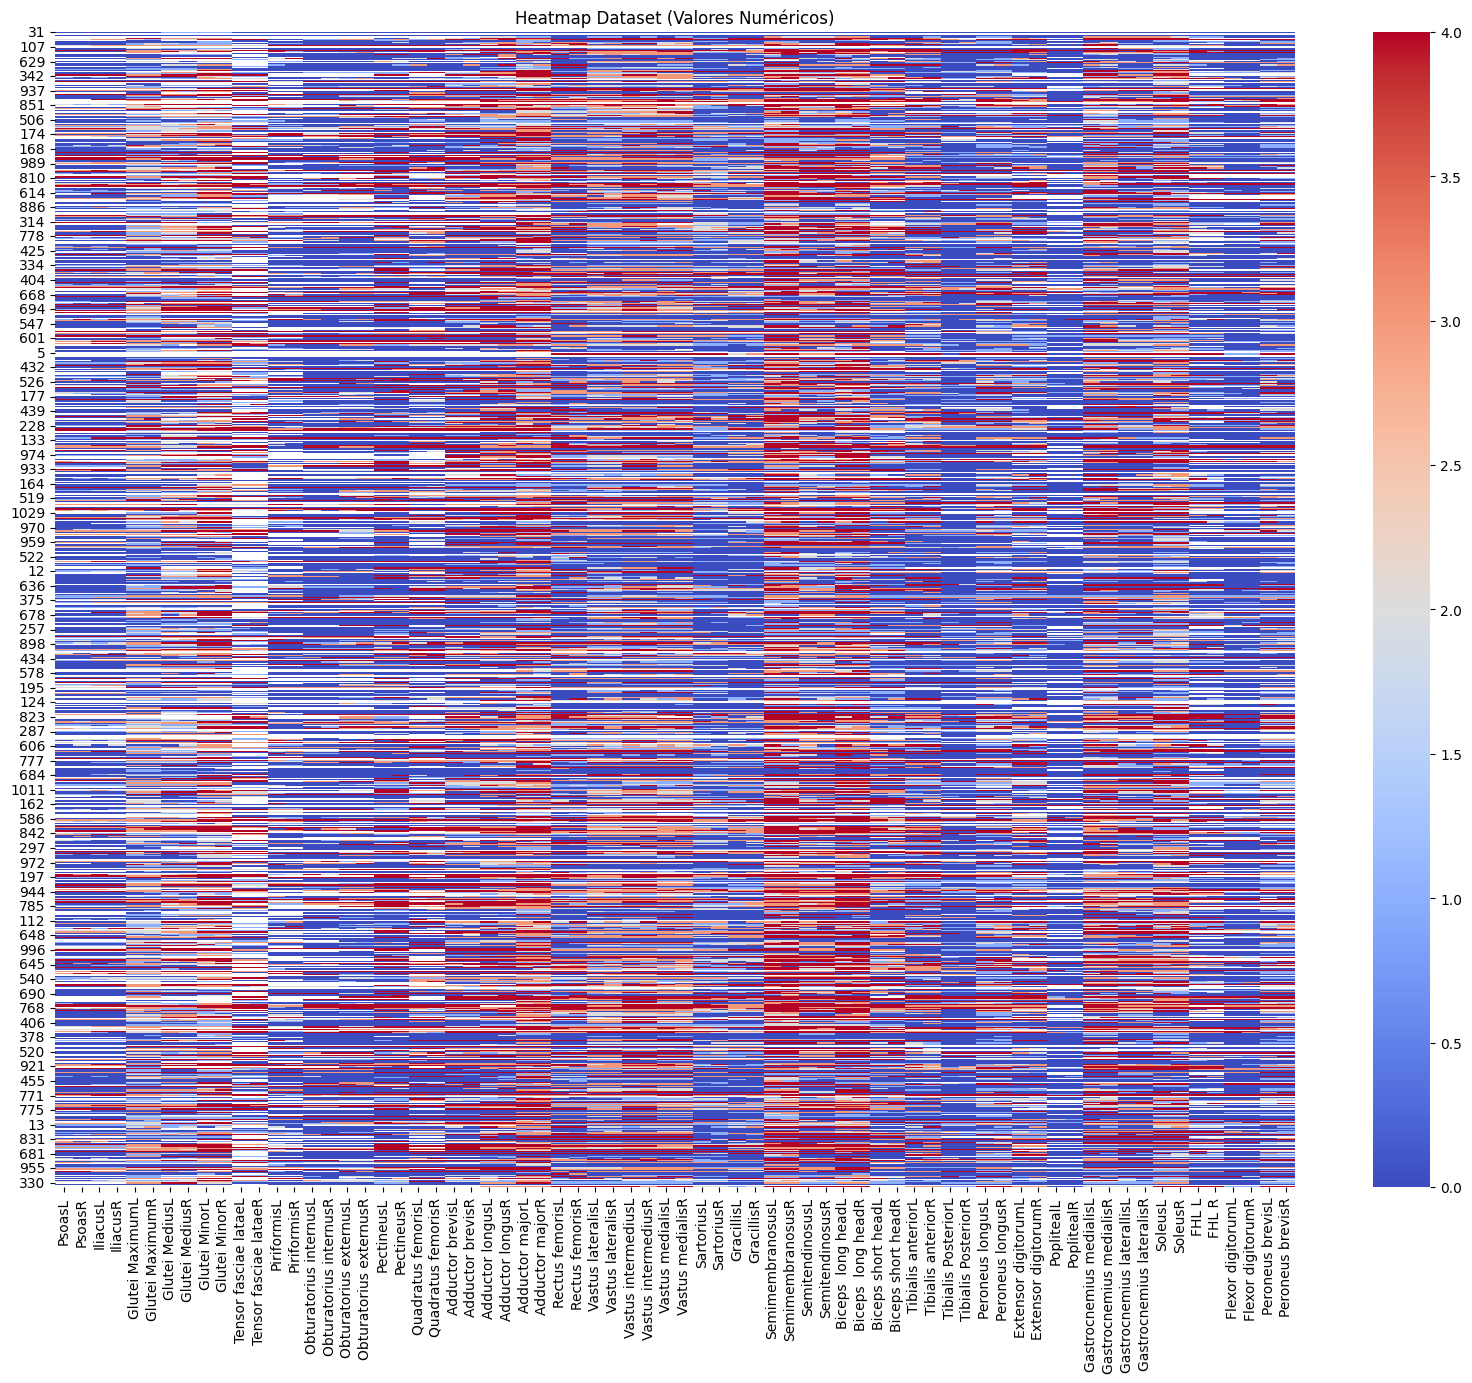

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

# Convert all columns to numeric, coercing errors to NaN
db_numeric = db_shuffled.apply(pd.to_numeric, errors='coerce')

plt.figure(figsize=(20, 15))
sns.heatmap(db_numeric, annot=False, cmap='coolwarm')
plt.title('Heatmap Dataset (Valores Numéricos)')
plt.show()

In [28]:
db_numeric.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1031 entries, 31 to 860
Data columns (total 70 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PsoasL                     723 non-null    float64
 1   PsoasR                     723 non-null    float64
 2   IliacusL                   732 non-null    float64
 3   IliacusR                   732 non-null    float64
 4   Glutei MaximumL            886 non-null    float64
 5   Glutei MaximumR            886 non-null    float64
 6   Glutei MediusL             796 non-null    float64
 7   Glutei MediusR             795 non-null    float64
 8   Glutei MinorL              791 non-null    float64
 9   Glutei MinorR              791 non-null    float64
 10  Tensor fasciae lataeL      575 non-null    float64
 11  Tensor fasciae lataeR      576 non-null    float64
 12  PiriformisL                686 non-null    float64
 13  PiriformisR                686 non-null    float64
 1

# Clustering Jerárquico

In [29]:
# Clustering Jerárquico

In [30]:

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

In [31]:
X = db_numeric.select_dtypes(include=[np.number]).copy()

In [33]:
imputer = SimpleImputer(strategy="median")
X_imp = imputer.fit_transform(X)

In [34]:
X_imp

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 1.],
       [0., 0., 0., ..., 0., 1., 1.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 1.],
       [0., 0., 0., ..., 1., 4., 4.]])

In [35]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imp)

In [38]:
use_pca = False
if use_pca:
    pca = PCA(n_components=0.95, svd_solver="full", random_state=42)
    X_emb = pca.fit_transform(X_scaled)
    print(f"PCA kept {pca.n_components_} components, explaining {pca.explained_variance_ratio_.sum():.3f} variance.")
else:
    X_emb = X_scaled

Z = linkage(X_emb, method="ward", metric="euclidean")

In [39]:
Z = linkage(X_emb, method="ward", metric="euclidean")

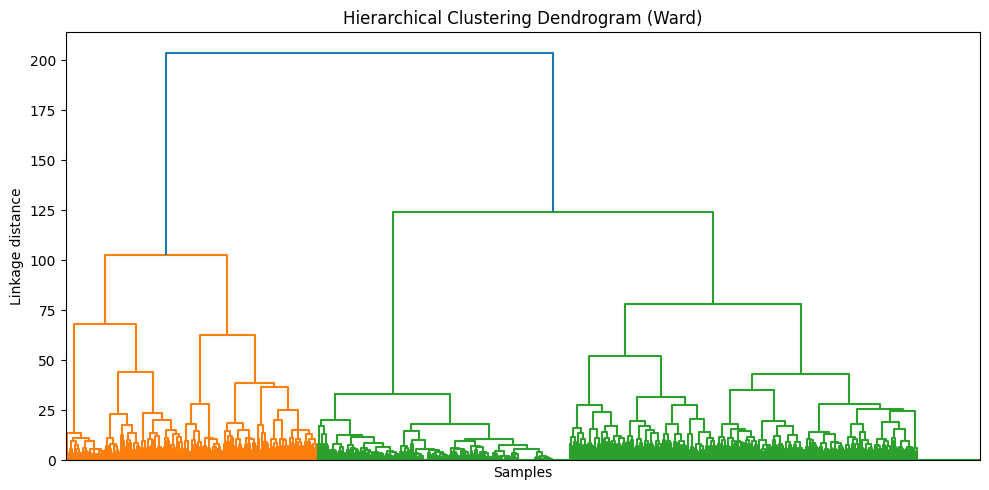

In [40]:
plt.figure(figsize=(10, 5))
dendrogram(Z, no_labels=True, count_sort=True)
plt.title("Hierarchical Clustering (Ward)")
plt.xlabel("Sujetos")
plt.ylabel("Linkage distance")
plt.tight_layout()
plt.show()

# Clustermap

/usr/local/lib/python3.11/dist-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/usr/local/lib/python3.11/dist-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


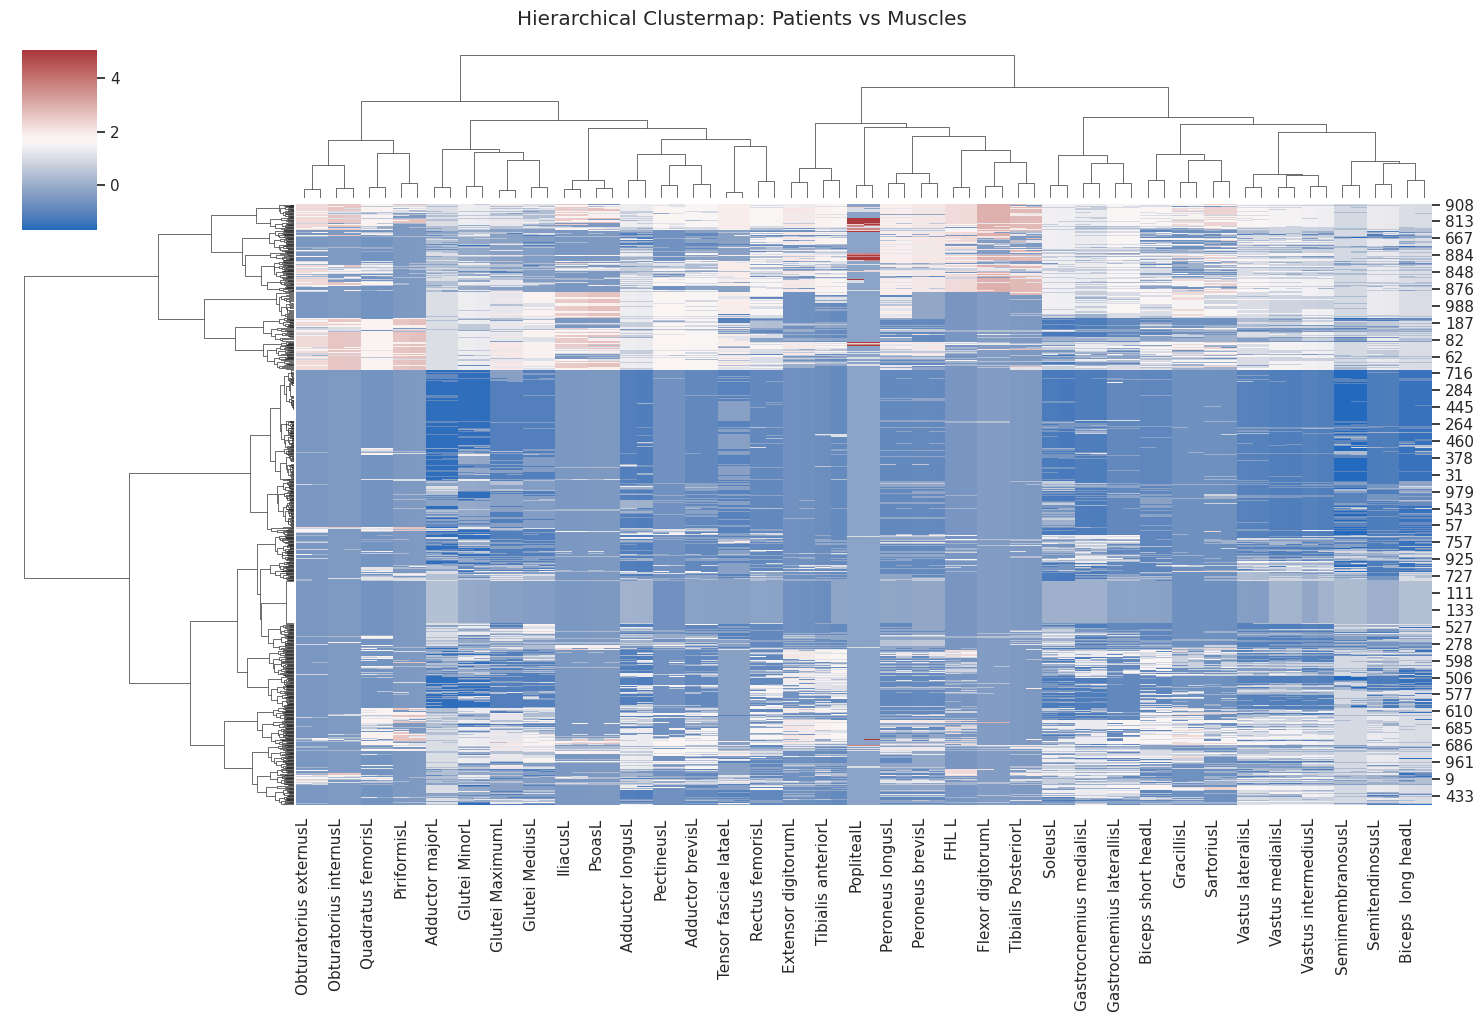

In [44]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# 1) Columnas numéricas
X = db_numeric.select_dtypes(include=[float, int]).copy()

# 2) Imputar datos
imputer = SimpleImputer(strategy="median")
X_imp = imputer.fit_transform(X)

# 3) Standarizar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imp)

# 4) Reconstruir el dataset
X_scaled_df = pd.DataFrame(X_scaled, index=X.index, columns=X.columns)

# 5) Clustermap
sns.set(context="notebook", style="white")
cg = sns.clustermap(
    X_scaled_df,
    method="ward",       # linkage method
    metric="euclidean",  # distance metric
    cmap="vlag",         # diverging colormap
    figsize=(15, 10),
    row_cluster=True,    # cluster patients
    col_cluster=True     # cluster muscles
)

# 6) Titulo
cg.fig.suptitle("Hierarchical Clustermap: Patients vs Muscles", y=1.02)

plt.show()

# Reducción de dimensionalidad

## PCA

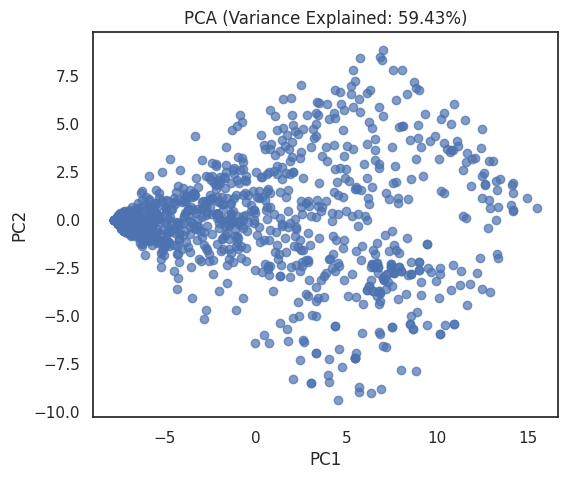

In [48]:
# --- Dimensionality Reduction with PCA, t-SNE, and UMAP ---
# Requirements:
# pip install pandas numpy scikit-learn umap-learn matplotlib ipywidgets

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import umap
import ipywidgets as widgets
from ipywidgets import interact

# 1) Preprocessing function
def preprocess_data(df):
    X = df.select_dtypes(include=[float, int]).copy()
    imputer = SimpleImputer(strategy="median")
    X_imp = imputer.fit_transform(X)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_imp)
    return X_scaled

# 2) Load your numeric data
X_scaled = preprocess_data(db_numeric)

# 3) PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.7)
plt.title(f"PCA (Variance Explained: {pca.explained_variance_ratio_.sum():.2%})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


In [50]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import plotly.express as px

# 1) Preprocesar datos
X = db_numeric.select_dtypes(include=[float, int]).copy()

# Imputar valores faltantes con la mediana
imputer = SimpleImputer(strategy="median")
X_imp = imputer.fit_transform(X)

# Escalar datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imp)

# 2) PCA a 3 componentes
pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# 3) DataFrame con componentes
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2", "PC3"],
    index=X.index
)

# 4) Gráfico 3D interactivo con Plotly
fig = px.scatter_3d(
    pca_df,
    x="PC1",
    y="PC2",
    z="PC3",
    opacity=0.7,
    title=f"PCA 3D Interactive (Explained Variance: {pca.explained_variance_ratio_.sum():.2%})"
)

fig.update_traces(marker=dict(size=4))
fig.show()

# tSNE

In [51]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import ipywidgets as widgets
from ipywidgets import interact
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from mpl_toolkits.mplot3d import Axes3D  # Needed for 3D plotting

# --- Preprocesamiento ---
X = db_numeric.select_dtypes(include=[float, int]).copy()
imputer = SimpleImputer(strategy="median")
X_imp = imputer.fit_transform(X)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imp)

# --- t-SNE interactivo ---
@interact(
    perplexity=widgets.IntSlider(value=30, min=5, max=50, step=1, description='Perplexity'),
    dims=widgets.Dropdown(options=[2, 3], value=2, description='Dimensions')
)
def plot_tsne(perplexity, dims):
    tsne = TSNE(
        n_components=dims,
        perplexity=perplexity,
        learning_rate='auto',
        init='pca',
        random_state=42
    )
    X_tsne = tsne.fit_transform(X_scaled)

    if dims == 2:
        plt.figure(figsize=(6,5))
        plt.scatter(X_tsne[:,0], X_tsne[:,1], alpha=0.7)
        plt.title(f"t-SNE 2D (perplexity={perplexity})")
        plt.xlabel("Dim 1")
        plt.ylabel("Dim 2")
        plt.show()

    elif dims == 3:
        fig = plt.figure(figsize=(7,6))
        ax = fig.add_subplot(111, projection='3d')
        ax.scatter(X_tsne[:,0], X_tsne[:,1], X_tsne[:,2], alpha=0.7)
        ax.set_title(f"t-SNE 3D (perplexity={perplexity})")
        ax.set_xlabel("Dim 1")
        ax.set_ylabel("Dim 2")
        ax.set_zlabel("Dim 3")
        plt.show()

interactive(children=(IntSlider(value=30, description='Perplexity', max=50, min=5), Dropdown(description='Dime…

## UMAP

In [52]:
import umap
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # Needed for 3D plotting
import ipywidgets as widgets
from ipywidgets import interact


# --- Preprocesamiento ---
X = db_numeric.select_dtypes(include=[float, int]).copy()
imputer = SimpleImputer(strategy="median")
X_imp = imputer.fit_transform(X)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imp)

# --- UMAP interactivo ---
@interact(
    n_neighbors=widgets.IntSlider(value=15, min=2, max=100, step=1, description='n_neighbors'),
    dims=widgets.Dropdown(options=[2, 3], value=2, description='Dimensions')
)
def plot_umap(n_neighbors, dims):
    reducer = umap.UMAP(
        n_components=dims,
        n_neighbors=n_neighbors,
        random_state=42,
        min_dist=0.1
    )
    X_umap = reducer.fit_transform(X_scaled)

    if dims == 2:
        plt.figure(figsize=(6,5))
        plt.scatter(X_umap[:,0], X_umap[:,1], alpha=0.7)
        plt.title(f"UMAP 2D (n_neighbors={n_neighbors})")
        plt.xlabel("Dim 1")
        plt.ylabel("Dim 2")
        plt.show()

    elif dims == 3:
        fig = plt.figure(figsize=(7,6))
        ax = fig.add_subplot(111, projection='3d')
        ax.scatter(X_umap[:,0], X_umap[:,1], X_umap[:,2], alpha=0.7)
        ax.set_title(f"UMAP 3D (n_neighbors={n_neighbors})")
        ax.set_xlabel("Dim 1")
        ax.set_ylabel("Dim 2")
        ax.set_zlabel("Dim 3")
        plt.show()

interactive(children=(IntSlider(value=15, description='n_neighbors', min=2), Dropdown(description='Dimensions'…

# Clustering

/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



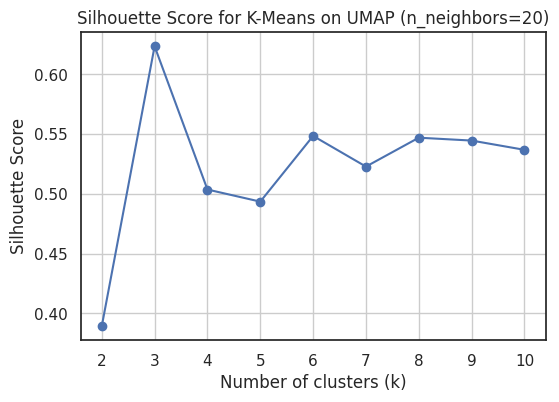

Best k = 3 with silhouette score = 0.624


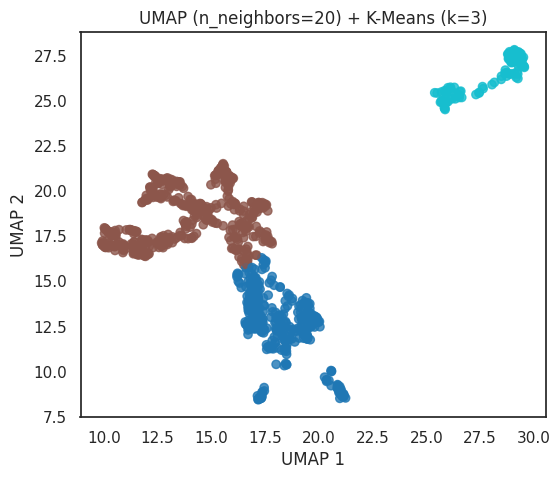

In [54]:
import umap
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import numpy as np

# --- Preprocesamiento ---
X = db_numeric.select_dtypes(include=[float, int]).copy()
imputer = SimpleImputer(strategy="median")
X_imp = imputer.fit_transform(X)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imp)

# --- UMAP 2D con n_neighbors = 20 ---
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=20,
    random_state=42,
    min_dist=0.1
)
X_umap_2d = reducer.fit_transform(X_scaled)

# --- K-Means para k = 1 a 10 ---
silhouette_scores = []
k_values = range(2, 11)  # silhouette no es válido para k=1

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_umap_2d)
    score = silhouette_score(X_umap_2d, labels)
    silhouette_scores.append(score)

# --- Gráfico de Silhouette Score ---
plt.figure(figsize=(6,4))
plt.plot(k_values, silhouette_scores, marker='o')
plt.title("Silhouette Score for K-Means on UMAP (n_neighbors=20)")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(k_values)
plt.grid(True)
plt.show()

# --- Opción: Mejor k ---
best_k = k_values[int(np.argmax(silhouette_scores))]
print(f"Best k = {best_k} with silhouette score = {max(silhouette_scores):.3f}")

# --- Visualización con el mejor k ---
kmeans_best = KMeans(n_clusters=best_k, random_state=42)
labels_best = kmeans_best.fit_predict(X_umap_2d)

plt.figure(figsize=(6,5))
plt.scatter(X_umap_2d[:,0], X_umap_2d[:,1], c=labels_best, cmap='tab10', alpha=0.8)
plt.title(f"UMAP (n_neighbors=20) + K-Means (k={best_k})")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.show()

In [58]:
# Requirements (in Jupyter):
# pip install umap-learn ipywidgets
# jupyter nbextension enable --py widgetsnbextension  # (si usas Jupyter clásico)

import umap
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import ipywidgets as widgets
from ipywidgets import interact

# Optional: simple cache to avoid recomputing UMAP for the same n_neighbors
_umap_cache = {}

def get_umap_embedding(X_scaled, n_neighbors, min_dist=0.1, random_state=42):
    key = (n_neighbors, min_dist)
    if key not in _umap_cache:
        reducer = umap.UMAP(
            n_components=2,
            n_neighbors=n_neighbors,
            min_dist=min_dist,
            random_state=random_state
        )
        _umap_cache[key] = reducer.fit_transform(X_scaled)
    return _umap_cache[key]

@interact(
    n_neighbors=widgets.IntSlider(value=20, min=2, max=100, step=1, description='n_neighbors'),
    k=widgets.IntSlider(value=3, min=2, max=15, step=1, description='k (KMeans)')
)
def umap_kmeans_interactive(n_neighbors, k):
    # 1) UMAP 2D
    X_umap_2d = get_umap_embedding(X_scaled, n_neighbors=n_neighbors, min_dist=0.1, random_state=42)

    # 2) K-Means
    kmeans = KMeans(n_clusters=k, n_init='auto', random_state=42)
    labels = kmeans.fit_predict(X_umap_2d)

    # 3) Silhouette (válido si hay >1 cluster único)
    score = np.nan
    if len(np.unique(labels)) > 1:
        score = silhouette_score(X_umap_2d, labels)

    # 4) Plot
    plt.figure(figsize=(7,6))
    sc = plt.scatter(X_umap_2d[:, 0], X_umap_2d[:, 1], c=labels, cmap='tab10', alpha=0.85, s=18)
    centers = kmeans.cluster_centers_
    plt.scatter(centers[:,0], centers[:,1], c='k', s=70, marker='x', label='Centroids')

    title = f"UMAP (n_neighbors={n_neighbors}) + K-Means (k={k})"
    if not np.isnan(score):
        title += f"  |  Silhouette = {score:.3f}"
    plt.title(title)
    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")
    plt.legend(loc='best', frameon=True)
    plt.show()

interactive(children=(IntSlider(value=20, description='n_neighbors', min=2), IntSlider(value=3, description='k…

## UMAP - DBSCAN

/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



eps | n_clusters | silhouette
0.50 | 19 | 0.2766464352607727
1.00 | 9 | 0.4451444745063782
1.50 | 6 | 0.29273751378059387
2.00 | 6 | 0.29273751378059387
2.50 | 4 | 0.22450920939445496
3.00 | 3 | 0.19795486330986023
3.50 | 3 | 0.19795486330986023
4.00 | 3 | 0.19795486330986023
4.50 | 3 | 0.19795486330986023
5.00 | 1 | ---

Best eps = 1.00 with silhouette = 0.445


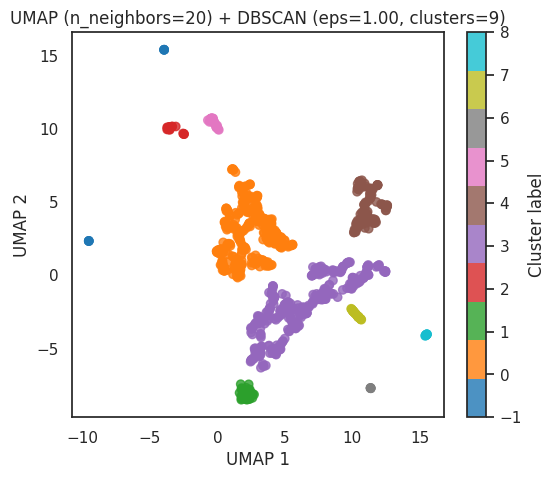

In [57]:
import umap
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import numpy as np

# --- Preprocesamiento ---
X = db_numeric.select_dtypes(include=[float, int]).copy()
imputer = SimpleImputer(strategy="median")
X_imp = imputer.fit_transform(X)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imp)

# --- UMAP 2D con n_neighbors = 20 ---
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=5,
    random_state=42,
    min_dist=0.1
)
X_umap_2d = reducer.fit_transform(X_scaled)

# --- Búsqueda de parámetros DBSCAN ---
eps_values = np.linspace(0.5, 5.0, 10)  # Rango de eps
min_samples = 5                          # Fijo para este ejemplo

results = []
for eps in eps_values:
    db = DBSCAN(eps=eps, min_samples=min_samples)
    labels = db.fit_predict(X_umap_2d)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    if n_clusters > 1:  # silhouette solo tiene sentido si hay más de un cluster
        score = silhouette_score(X_umap_2d, labels)
    else:
        score = np.nan
    results.append((eps, n_clusters, score))

# Mostrar resultados
print("eps | n_clusters | silhouette")
for eps, n_clusters, score in results:
    print(f"{eps:.2f} | {n_clusters} | {score if not np.isnan(score) else '---'}")

# --- Elegir el mejor eps según silhouette ---
valid_results = [(eps, score) for eps, _, score in results if not np.isnan(score)]
best_eps, best_score = max(valid_results, key=lambda x: x[1])
print(f"\nBest eps = {best_eps:.2f} with silhouette = {best_score:.3f}")

# --- DBSCAN final con best_eps ---
db_best = DBSCAN(eps=best_eps, min_samples=min_samples)
labels_best = db_best.fit_predict(X_umap_2d)
n_clusters_best = len(set(labels_best)) - (1 if -1 in labels_best else 0)

# --- Visualización ---
plt.figure(figsize=(6,5))
scatter = plt.scatter(
    X_umap_2d[:,0],
    X_umap_2d[:,1],
    c=labels_best,
    cmap='tab10',
    alpha=0.8
)
plt.title(f"UMAP (n_neighbors=20) + DBSCAN (eps={best_eps:.2f}, clusters={n_clusters_best})")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.colorbar(scatter, label="Cluster label")
plt.show()

# ¿Cómo eran realmente?